In [1]:
import os
from glob import glob
import numpy as np
from scipy.stats import median_abs_deviation


from scipy.sparse import csr_matrix
import pandas as pd
import scanpy as sc
import anndata as ad
import pybiomart as bm
import seaborn as sns

In [2]:
###BioMart da problemi, creo pickle dictionary dalla cartella e10 per il genoma murino e i geni mitocondriali, e lo importo qui###
import pickle
with open("/home/users/roberto.oleari/sc_e10.5/mm_genes_dump.pkl", "rb") as f:
    mm_genes = pickle.load(f)

In [3]:
mm_genes

,Gene stable ID,Gene name
0,ENSMUSG00000104478,Gm38212
1,ENSMUSG00000104385,Gm7449
2,ENSMUSG00000101231,Gm28283
3,ENSMUSG00000101097,Gm6679
4,ENSMUSG00000100764,Gm29155
...,...,...
78270,ENSMUSG00000101124,Gm28371
78271,ENSMUSG00000137367,Gm28371
78272,ENSMUSG00000094529,Gm21744
78273,ENSMUSG00000143682,Gm58340


In [4]:
# rename the columns
mm_genes = mm_genes.rename(columns={"Gene stable ID": "gene_ids", "Gene name": "gene_name"})

In [5]:
with open("/home/users/roberto.oleari/sc_e10.5/mm_MT_dump.pkl", "rb") as f:
    mm_MT = pickle.load(f)

In [6]:
mm_MT.head()

,Gene stable ID,Gene name
0,ENSMUSG00000064336,mt-Tf
1,ENSMUSG00000064337,mt-Rnr1
2,ENSMUSG00000064338,mt-Tv
3,ENSMUSG00000064339,mt-Rnr2
4,ENSMUSG00000064340,mt-Tl1


In [7]:
mm_MT.shape


(37, 2)

In [8]:
def sc_preprocess(path: str, gene_annot: pd.DataFrame):
    
    print("1. Reading data matrix")
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    
    print("2. Adding gene metadata")
    gene_annot = adata.var.merge(gene_annot, how="left", on="gene_ids")
    gene_annot.set_index(adata.var.index, inplace=True)
    
    if (adata.var["gene_ids"] == gene_annot["gene_ids"]).all():
        adata.var = gene_annot
    else: 
        print("The gene order was not the same!")
        return
    
    adata.var["mt"] = False
    adata.var.loc[adata.var.gene_ids.isin(mm_MT['Gene stable ID']), "mt"] = True

    

    print("3. Calculating QC metrics and filtering")
    # Generate qc metrics
    sc.pp.calculate_qc_metrics(
        adata, 
        qc_vars=["mt"], 
        inplace=True, percent_top=[20], 
        log1p=True
        )
    
    # Identify outliers per qc metric
    adata.obs["counts_outlier"] = is_outlier(adata, "log1p_total_counts", 5)
    adata.obs["genes_outlier"] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
    adata.obs["topgenes_outlier"] = is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    adata.obs["mito_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] > 8)

    # Identify outliers based on ALL qc metrics 
    adata.obs["outlier"] = (
        adata.obs["counts_outlier"]  
        | adata.obs["genes_outlier"] 
        | adata.obs["topgenes_outlier"] 
        | adata.obs["mito_outlier"]
    )
    # Remove outliers
    adata = adata[~adata.obs["outlier"]].copy()

    # Perform gene filtering
    sc.pp.filter_genes(adata, min_cells=1)

    # Remove doublets
    sc.pp.scrublet(adata)
    adata = adata[~adata.obs["predicted_doublet"], :].copy()

    print("4. Applying normalisations")
    adata.layers["counts"] = adata.X.copy()

    sc.pp.normalize_total(adata, target_sum=10000)
    sc.pp.log1p(adata)

    return adata

# our outlier detection function from before
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [32]:
sample_info = pd.read_table("./e12_sample_sheet.tsv")
sample_info = sample_info.rename(columns={"Sample": "sample_id", 
                                          "SampleName": "sample_name", 
                                          "SampleGroup": "sample_group"})
sample_info

,sample_id,sample_name,sample_group
0,face_1,e12_1,WT
1,face_2,e12_2,WT
2,face_4,e12_3,WT


In [10]:
# create a dictionary to hold all AnnData objects
adata = dict.fromkeys(sample_info["sample_id"])

# read all samples
for sample in adata.keys():
  print(f"\nReading {sample}")
  adata[sample] = sc_preprocess(
    f"./cellranger_count_E12_5_{sample}_filtered_feature_bc_matrix.h5/",
    mm_genes
    )


Reading face_1
1. Reading data matrix


/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


2. Adding gene metadata
3. Calculating QC metrics and filtering
4. Applying normalisations

Reading face_2
1. Reading data matrix


/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


2. Adding gene metadata
3. Calculating QC metrics and filtering
4. Applying normalisations

Reading face_4
1. Reading data matrix


/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/users/roberto.oleari/mambaforge/envs/py310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


2. Adding gene metadata
3. Calculating QC metrics and filtering
4. Applying normalisations


In [11]:
type(adata)

dict

In [12]:
adata

{'face_1': AnnData object with n_obs × n_vars = 5109 × 23709
     obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet'
     var: 'gene_ids', 'feature_types', 'genome', 'interval', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'scrublet', 'log1p'
     layers: 'counts',
 'face_2': AnnData object with n_obs × n_vars = 5458 × 23450
     obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet'
   

In [13]:
### SALVO DICT DI ADATA OBJ --> evita di fare eseguire funzione pre-processing tutte le volte ###
import pickle
with open("results_e12.pkl", "wb") as o:
    pickle.dump(adata, o)

In [9]:
### RIPARTI DA QUI PER SALTARE FUNZIONE PRE-PROCESSING ###
# metti True per far eseguire: carica il dizionario serializzato dentro la variabile <adata>
import pickle
if True:
    with open("results_e12.pkl", "rb") as f:
        adata = pickle.load(f)

In [10]:
adata

{'face_1': AnnData object with n_obs × n_vars = 5109 × 23709
     obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet'
     var: 'gene_ids', 'feature_types', 'genome', 'interval', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'scrublet', 'log1p'
     layers: 'counts',
 'face_2': AnnData object with n_obs × n_vars = 5458 × 23450
     obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet'
   

In [11]:
# estraggo tutti i geni dal dict e li metto in una lista che poi trasformo in DataFrame
all_var = [x.var for x in adata.values()]

all_var

[                          gene_ids    feature_types genome  \
 Xkr4            ENSMUSG00000051951  Gene Expression   mm10   
 Gm1992          ENSMUSG00000089699  Gene Expression   mm10   
 Gm19938         ENSMUSG00000102331  Gene Expression   mm10   
 Rp1             ENSMUSG00000025900  Gene Expression   mm10   
 Sox17           ENSMUSG00000025902  Gene Expression   mm10   
 ...                            ...              ...    ...   
 Tmlhe           ENSMUSG00000079834  Gene Expression   mm10   
 4933409K07Rik   ENSMUSG00000095552  Gene Expression   mm10   
 Gm10931         ENSMUSG00000094350  Gene Expression   mm10   
 CAAA01147332.1  ENSMUSG00000095742  Gene Expression   mm10   
 AC149090.1      ENSMUSG00000095041  Gene Expression   mm10   
 
                                 interval gene_name     mt  n_cells_by_counts  \
 Xkr4                chr1:3671497-3671498      Xkr4  False                375   
 Gm1992              chr1:3466586-3466587    Gm1992  False                  4   

In [12]:
type(all_var)

list

In [13]:
# concatenate them - join="outer" è inutile se tengo tutte le colonne perchè ci sarà un valore diverso per forza in almeno una colonna!!!
all_var = pd.concat(all_var, join="outer")

all_var

,gene_ids,feature_types,genome,interval,gene_name,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,chr1:3671497-3671498,Xkr4,False,375,0.183024,0.168074,94.473917,1242.0,7.125283,307
Gm1992,ENSMUSG00000089699,Gene Expression,mm10,chr1:3466586-3466587,Gm1992,False,4,0.000589,0.000589,99.941055,4.0,1.609438,3
Gm19938,ENSMUSG00000102331,Gene Expression,mm10,chr1:3658903-3658904,Gm19938,False,31,0.005305,0.005291,99.543177,36.0,3.610918,26
Rp1,ENSMUSG00000025900,Gene Expression,mm10,chr1:4360313-4409241,Rp1,False,17,0.003389,0.003384,99.749484,23.0,3.178054,12
Sox17,ENSMUSG00000025902,Gene Expression,mm10,chr1:4496362-4497354,Sox17,False,53,0.012084,0.012011,99.218980,82.0,4.418840,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tmlhe,ENSMUSG00000079834,Gene Expression,mm10,GL456233.1:159646-159647,NaN,False,3457,0.519984,0.418700,65.714569,5243.0,8.564840,2810
4933409K07Rik,ENSMUSG00000095552,Gene Expression,mm10,JH584293.1:140955-140956,NaN,False,47,0.004661,0.004650,99.533869,47.0,3.871201,38
Gm10931,ENSMUSG00000094350,Gene Expression,mm10,JH584294.1:137008-137009,NaN,False,1,0.000099,0.000099,99.990082,1.0,0.693147,1
CAAA01147332.1,ENSMUSG00000095742,Gene Expression,mm10,JH584295.1:1478-1479,NaN,False,25,0.002479,0.002476,99.752058,25.0,3.258096,21


In [14]:
type(all_var)

pandas.core.frame.DataFrame

In [15]:
# tengo solo le colonne di interesse
all_var = all_var[["gene_ids", "gene_name", "mt"]]

all_var

,gene_ids,gene_name,mt
Xkr4,ENSMUSG00000051951,Xkr4,False
Gm1992,ENSMUSG00000089699,Gm1992,False
Gm19938,ENSMUSG00000102331,Gm19938,False
Rp1,ENSMUSG00000025900,Rp1,False
Sox17,ENSMUSG00000025902,Sox17,False
...,...,...,...
Tmlhe,ENSMUSG00000079834,NaN,False
4933409K07Rik,ENSMUSG00000095552,NaN,False
Gm10931,ENSMUSG00000094350,NaN,False
CAAA01147332.1,ENSMUSG00000095742,NaN,False


In [16]:
# rimuovo i duplicati 
### NB --> devo farlo su .index e non su qualsiasi colonna altrimenti può dare errore poi quando faccio merge
### duplicated() assegna boolean True/False / tilde ribalta i valori

all_var = all_var[~all_var.index.duplicated()]

all_var

,gene_ids,gene_name,mt
Xkr4,ENSMUSG00000051951,Xkr4,False
Gm1992,ENSMUSG00000089699,Gm1992,False
Gm19938,ENSMUSG00000102331,Gm19938,False
Rp1,ENSMUSG00000025900,Rp1,False
Sox17,ENSMUSG00000025902,Sox17,False
...,...,...,...
Gm28961,ENSMUSG00000101399,Gm28961,False
Gm20937,ENSMUSG00000096016,Gm20937,False
Gm29564,ENSMUSG00000099792,Gm29564,False
Gm28102,ENSMUSG00000101915,Gm28102,False


In [26]:
#all_var aveva 71730 rows --> ora ne ha 26225 

In [27]:
#concateno gli adata obj del dict in un nuovo AnnData Obj
adata_combined = sc.concat(adata, join="outer", label="sample_id", index_unique="-")


In [28]:
adata_combined.var

""
0610005C13Rik
0610006L08Rik
0610009B22Rik
0610009E02Rik
0610009L18Rik
...
mt-Nd3
mt-Nd4
mt-Nd4l
mt-Nd5


In [20]:
adata_combined.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,counts_outlier,genes_outlier,topgenes_outlier,mito_outlier,outlier,doublet_score,predicted_doublet,sample_id
AAACAGCCAACTAACT-1-face_1,2413,7.789040,4951.0,8.507546,12.441931,158.0,5.068904,3.191274,False,False,False,False,False,0.055556,False,face_1
AAACAGCCAGCTTACA-1-face_1,1752,7.469084,3040.0,8.019941,12.335526,78.0,4.369448,2.565789,False,False,False,False,False,0.039389,False,face_1
AAACATGCAAGGGTTG-1-face_1,2233,7.711549,3967.0,8.286017,8.520292,14.0,2.708050,0.352912,False,False,False,False,False,0.020701,False,face_1
AAACATGCACCGTTCC-1-face_1,2057,7.629490,3908.0,8.271037,9.570113,133.0,4.897840,3.403275,False,False,False,False,False,0.030612,False,face_1
AAACATGCACCTAATG-1-face_1,2503,7.825645,5698.0,8.648046,13.899614,114.0,4.744932,2.000702,False,False,False,False,False,0.060278,False,face_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCCTTGCGT-1-face_4,1570,7.359468,2484.0,7.818028,11.272142,23.0,3.178054,0.925926,False,False,False,False,False,0.016927,False,face_4
TTTGTGTTCTAAGGAG-1-face_4,2287,7.735433,4720.0,8.459776,11.546610,39.0,3.688879,0.826271,False,False,False,False,False,0.058240,False,face_4
TTTGTGTTCTAGCTAA-1-face_4,2038,7.620215,3670.0,8.208220,9.346049,4.0,1.609438,0.108992,False,False,False,False,False,0.042339,False,face_4
TTTGTGTTCTTGAGCG-1-face_4,1714,7.447168,2539.0,7.839920,6.931863,8.0,2.197225,0.315085,False,False,False,False,False,0.022818,False,face_4


In [29]:
#riassegno i metadati dei geni storati in all_var al nuovo AnnData Obj
adata_combined.var = all_var.loc[adata_combined.var_names]

In [30]:
adata_combined.var

,gene_ids,gene_name,mt
0610005C13Rik,ENSMUSG00000109644,0610005C13Rik,False
0610006L08Rik,ENSMUSG00000108652,0610006L08Rik,False
0610009B22Rik,ENSMUSG00000007777,Trappc2b,False
0610009E02Rik,ENSMUSG00000086714,0610009E02Rik,False
0610009L18Rik,ENSMUSG00000043644,0610009L18Rik,False
...,...,...,...
mt-Nd3,ENSMUSG00000064360,mt-Nd3,True
mt-Nd4,ENSMUSG00000064363,mt-Nd4,True
mt-Nd4l,ENSMUSG00000065947,mt-Nd4l,True
mt-Nd5,ENSMUSG00000064367,mt-Nd5,True


In [33]:
#alle cellule assegno i sample group 
adata_combined.obs = (
  adata_combined.obs
  .merge(sample_info, how="left", on="sample_id")
  .set_axis(adata_combined.obs.index)
)

In [34]:
adata_combined.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,counts_outlier,genes_outlier,topgenes_outlier,mito_outlier,outlier,doublet_score,predicted_doublet,sample_id,sample_name,sample_group
AAACAGCCAACTAACT-1-face_1,2413,7.789040,4951.0,8.507546,12.441931,158.0,5.068904,3.191274,False,False,False,False,False,0.055556,False,face_1,e12_1,WT
AAACAGCCAGCTTACA-1-face_1,1752,7.469084,3040.0,8.019941,12.335526,78.0,4.369448,2.565789,False,False,False,False,False,0.039389,False,face_1,e12_1,WT
AAACATGCAAGGGTTG-1-face_1,2233,7.711549,3967.0,8.286017,8.520292,14.0,2.708050,0.352912,False,False,False,False,False,0.020701,False,face_1,e12_1,WT
AAACATGCACCGTTCC-1-face_1,2057,7.629490,3908.0,8.271037,9.570113,133.0,4.897840,3.403275,False,False,False,False,False,0.030612,False,face_1,e12_1,WT
AAACATGCACCTAATG-1-face_1,2503,7.825645,5698.0,8.648046,13.899614,114.0,4.744932,2.000702,False,False,False,False,False,0.060278,False,face_1,e12_1,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCCTTGCGT-1-face_4,1570,7.359468,2484.0,7.818028,11.272142,23.0,3.178054,0.925926,False,False,False,False,False,0.016927,False,face_4,e12_3,WT
TTTGTGTTCTAAGGAG-1-face_4,2287,7.735433,4720.0,8.459776,11.546610,39.0,3.688879,0.826271,False,False,False,False,False,0.058240,False,face_4,e12_3,WT
TTTGTGTTCTAGCTAA-1-face_4,2038,7.620215,3670.0,8.208220,9.346049,4.0,1.609438,0.108992,False,False,False,False,False,0.042339,False,face_4,e12_3,WT
TTTGTGTTCTTGAGCG-1-face_4,1714,7.447168,2539.0,7.839920,6.931863,8.0,2.197225,0.315085,False,False,False,False,False,0.022818,False,face_4,e12_3,WT


<Axes: xlabel='pct_counts_mt', ylabel='Count'>

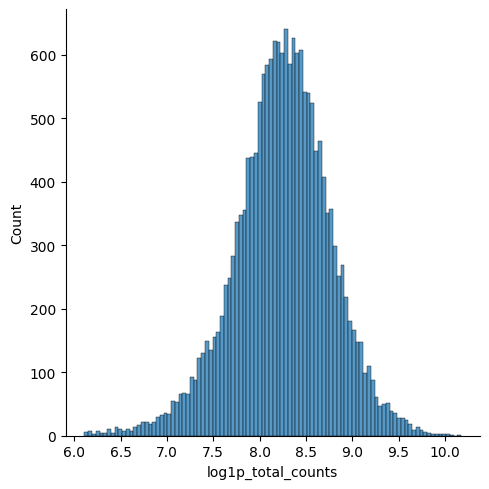

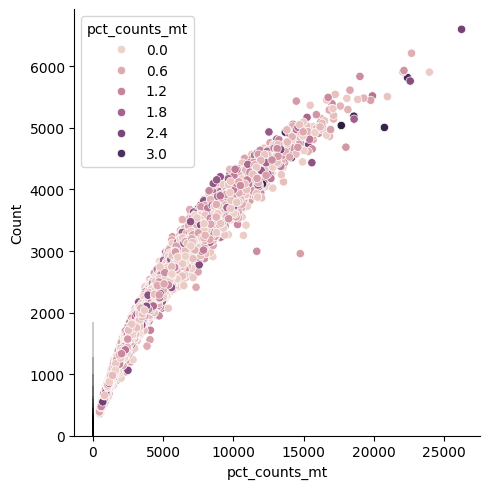

In [35]:
sns.displot(adata_combined.obs, x="log1p_total_counts", bins=100)
sns.displot(adata_combined.obs, x="pct_counts_mt", bins=100)
sns.scatterplot(adata_combined.obs, x="total_counts", y="n_genes_by_counts", hue="pct_counts_mt")

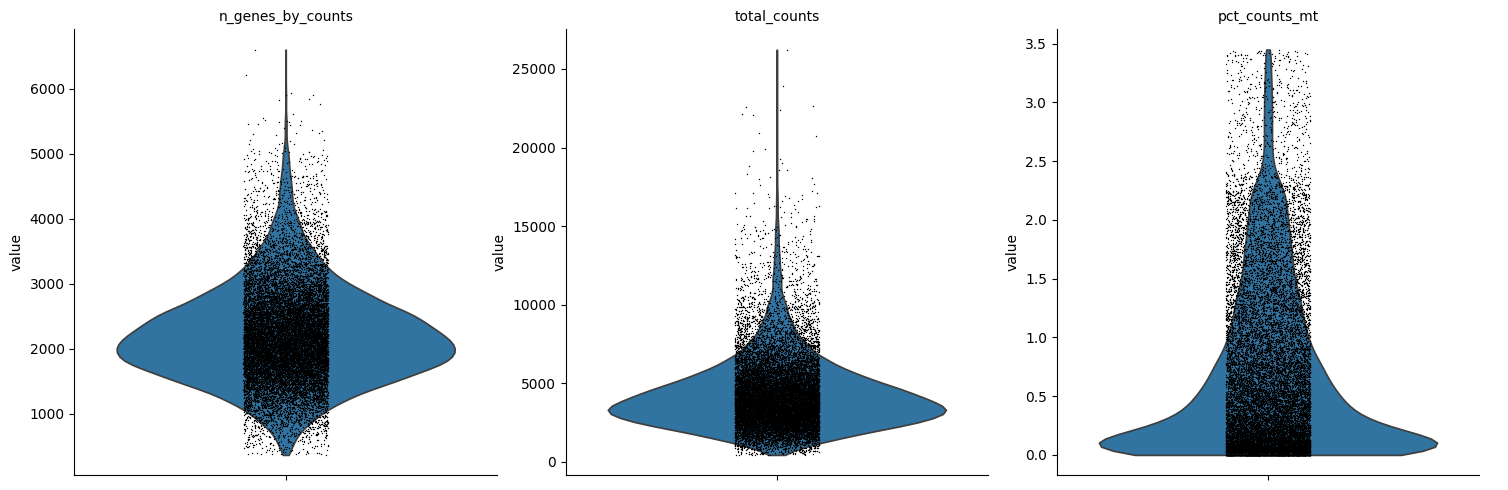

In [36]:
sc.pl.violin(
  adata_combined,
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  multi_panel=True
)

In [37]:
adata_combined.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,counts_outlier,genes_outlier,topgenes_outlier,mito_outlier,outlier,doublet_score,predicted_doublet,sample_id,sample_name,sample_group
AAACAGCCAACTAACT-1-face_1,2413,7.789040,4951.0,8.507546,12.441931,158.0,5.068904,3.191274,False,False,False,False,False,0.055556,False,face_1,e12_1,WT
AAACAGCCAGCTTACA-1-face_1,1752,7.469084,3040.0,8.019941,12.335526,78.0,4.369448,2.565789,False,False,False,False,False,0.039389,False,face_1,e12_1,WT
AAACATGCAAGGGTTG-1-face_1,2233,7.711549,3967.0,8.286017,8.520292,14.0,2.708050,0.352912,False,False,False,False,False,0.020701,False,face_1,e12_1,WT
AAACATGCACCGTTCC-1-face_1,2057,7.629490,3908.0,8.271037,9.570113,133.0,4.897840,3.403275,False,False,False,False,False,0.030612,False,face_1,e12_1,WT
AAACATGCACCTAATG-1-face_1,2503,7.825645,5698.0,8.648046,13.899614,114.0,4.744932,2.000702,False,False,False,False,False,0.060278,False,face_1,e12_1,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCCTTGCGT-1-face_4,1570,7.359468,2484.0,7.818028,11.272142,23.0,3.178054,0.925926,False,False,False,False,False,0.016927,False,face_4,e12_3,WT
TTTGTGTTCTAAGGAG-1-face_4,2287,7.735433,4720.0,8.459776,11.546610,39.0,3.688879,0.826271,False,False,False,False,False,0.058240,False,face_4,e12_3,WT
TTTGTGTTCTAGCTAA-1-face_4,2038,7.620215,3670.0,8.208220,9.346049,4.0,1.609438,0.108992,False,False,False,False,False,0.042339,False,face_4,e12_3,WT
TTTGTGTTCTTGAGCG-1-face_4,1714,7.447168,2539.0,7.839920,6.931863,8.0,2.197225,0.315085,False,False,False,False,False,0.022818,False,face_4,e12_3,WT


In [38]:
adata_combined.obs["pct_counts_mt"].max()


np.float32(3.4499514)

In [39]:
adata_combined

AnnData object with n_obs × n_vars = 18203 × 26225
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet', 'sample_id', 'sample_name', 'sample_group'
    var: 'gene_ids', 'gene_name', 'mt'
    layers: 'counts'

In [40]:
adata_combined.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 40188442 stored elements and shape (18203, 26225)>

In [41]:
adata_combined.write_h5ad("e12_full_norm.h5ad")